# Surrogate Model — Email/Outbound Luggage Offer

Trains a CatBoost surrogate and a Naive Bayes robustness baseline to replicate Pega ADM propensity scores, then reports the full fidelity suite (R², RMSE, Spearman ρ, Kendall τ, KS).  
Saved artifacts feed notebooks 05 (explanation) onwards.

**Run `02_data_ingestion.ipynb` first.**

In [1]:
# ── Config ────────────────────────────────────────────────────────────────
# Change VARIANT to run on a different offer model.
from pathlib import Path
from my_project.parsing import THIRDPARTY_VARIANTS

VARIANT       = "Cartrawler"
PROCESSED_DIR = Path("../data/processed")
ARTIFACT_DIR  = Path("../data/artifacts") / VARIANT
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = PROCESSED_DIR / (
    "thirdparty_email_outbound.parquet" if VARIANT in THIRDPARTY_VARIANTS
    else "luggage_email_outbound.parquet"
)
print(f"Variant : {VARIANT}")
print(f"Input   : {PROCESSED_FILE}")
print(f"Artifacts → {ARTIFACT_DIR}")

Variant : Cartrawler
Input   : ..\data\processed\thirdparty_email_outbound.parquet
Artifacts → ..\data\artifacts\Cartrawler


In [2]:
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr as _spearmanr
from sklearn.model_selection import KFold, train_test_split

sys.path.insert(0, "../src")
from my_project.features import VARIANT_FEATURES
from my_project.metrics import feature_ranking, fidelity_suite
from my_project.surrogate import (
    NaiveBayesBaseline,
    build_feature_matrix,
    evaluate_surrogate,
    train_catboost,
)

print("Imports OK")

Imports OK


In [3]:
df = pd.read_parquet(PROCESSED_FILE)
# Filter to primary variant (pyName preserves original casing e.g. "BookingDotCom")
df = df[df["pyName"] == VARIANT].reset_index(drop=True)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Model versions: {df['modelVersion'].nunique()}")
print(df["modelVersion"].value_counts().to_string())

Rows: 42,160  |  Columns: 441
Model versions: 1717
modelVersion
5c2acbce-86df-50a0-b3ba-17a5f6a5270c    446
5ed27c75-0039-5c7f-9bda-d950ccf254df    416
b9116607-3620-526a-96f2-490303931dae    414
c77ad3f1-48a3-5d06-8dcd-376561a6ae52    410
6db6f699-1d07-5d4e-9b7e-54cc1ca6f99b    392
42e89e31-ee09-5bac-96a0-658988831fd7    386
a878af03-6183-53de-9357-1a9b294d3dba    384
3f17039f-88f1-5435-ba32-890ad55b698e    369
ac8ac396-4031-57cf-bf11-54bbf465325b    367
f9161152-526a-5d3b-a24a-21e643a500e3    366
ece43c87-1d4d-5bc3-b310-27e32ab67f25    364
0777b91e-2eda-5471-880a-7a648e983f0f    362
b335bafa-1b51-5662-b6b9-1a8462c839b5    359
267c0f90-0fb5-544e-8be8-9a77ff9cdbdf    350
1af6e524-d196-53e5-8485-c4e133001a00    350
6718038b-cd9f-559f-8ce3-f84f7a09ffbc    344
ca20c65f-6850-5f60-8e6a-2d086c4183a9    336
6e5566c8-fa43-5eb8-8dbc-bd8900fc9e74    319
998c98a1-04bf-5d88-a1df-f1b5c19a7491    317
e1f7c11a-4fbb-5109-95d9-1b75bfe6342a    316
810f32f6-3e75-583f-9af9-364d834fb025    314
16451dfc-db7

## 7. Surrogate Model

The surrogate approximates the black-box Pega ADM function $f$ using only the logged tuples $(X_i, \hat{p}_i)$. It serves as the prediction oracle for SHAP and LIME in notebook 05. Fidelity is measured on a held-out test set.

In [4]:
### 7.1  Feature matrix
cfg = VARIANT_FEATURES[VARIANT]
X, y, cat_cols, num_cols = build_feature_matrix(df, list(cfg.features), cfg.numeric)
print(f"Features: {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Target   : {y.describe().to_dict()}")
X.head(3)

Features: 25  (10 numeric, 15 categorical)
Target   : {'count': 42160.0, 'mean': 0.002138611822724781, 'std': 0.0012181893457304505, 'min': 0.00047329387845813204, '25%': 0.001805314743700683, '50%': 0.001938127317989158, '75%': 0.002189295530415226, 'max': 0.032568238213399506}


,param::Param.BundleName,CustBookedFlight.BookingData.CultureCode,CustBookedFlight.FlightData.AirlineCodeIATA,CustBookedFlight.BookingData.FlightInboundArrival,CustBookedFlight.FlightData.DepartureAirport,CustBookedFlight.BookingData.DurationOfJourney,CustBookedFlight.BookingData.FlightInboundDeparture,IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince,CustBookedFlight.Language,IH.Email.Outbound.Pending.pxLastOutcomeTime.DaysSince,...,CustBookedFlight.FlightData.DestinationAirport,CustBookedFlight.DepartureAirport,CustBookedFlight.IsStaffStandBy,IH.Email.Inbound.Clicked.pyHistoricalOutcomeCount,IH.Email.Inbound.Clicked.pxLastOutcomeTime.DaysSince,IH.Mobile.Inbound.Impression.pxLastOutcomeTime.DaysSince,IH.Email.Outbound.Clicked.pyHistoricalOutcomeCount,CustBookedFlight.SeatNumber,param::Param.FlightCost,param::Param.Age
0,BookingConfirmation,fr-FR,TO,__MISSING__,ORY,0.0,__MISSING__,NaN,French,NaN,...,TLN,ORY,__MISSING__,NaN,NaN,NaN,NaN,__MISSING__,264.0,56
1,__MISSING__,fr-FR,TO,__MISSING__,ORY,0.0,__MISSING__,NaN,French,NaN,...,TLN,ORY,__MISSING__,NaN,NaN,NaN,NaN,__MISSING__,NaN,__MISSING__
2,__MISSING__,__MISSING__,__MISSING__,__MISSING__,__MISSING__,7.0,__MISSING__,NaN,Dutch,NaN,...,__MISSING__,EIN,__MISSING__,NaN,NaN,NaN,NaN,__MISSING__,NaN,__MISSING__


In [5]:
### 7.2  Train / test split  (random 80/20, fixed seed)
# Temporal splits for stability analysis are defined in notebook 06.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 33,728  |  Test: 8,432


In [6]:
### 7.3  CatBoost — depth grid search (5-fold CV on Spearman ρ)
# The NB generating process is strictly additive (no feature interactions),
# so lower depths should generalise better. CV selects the optimal depth.

kf = KFold(n_splits=5, shuffle=True, random_state=42)
depth_results = []

for depth in range(1, 7):
    fold_rhos = []
    for tr_idx, val_idx in kf.split(X_train):
        m = train_catboost(
            X_train.iloc[tr_idx], y_train.iloc[tr_idx], cat_cols, depth=depth
        )
        rho, _ = _spearmanr(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx]))
        fold_rhos.append(rho)
    depth_results.append({
        "depth":    depth,
        "mean_rho": round(float(np.mean(fold_rhos)), 4),
        "std_rho":  round(float(np.std(fold_rhos)),  4),
    })

cv_df = pd.DataFrame(depth_results).set_index("depth")
display(cv_df.style.format("{:.4f}").highlight_max(subset=["mean_rho"], color="#d4edda"))

best_depth = int(cv_df["mean_rho"].idxmax())
print(f"\nSelected depth: {best_depth}")

cb_model    = train_catboost(X_train, y_train, cat_cols, depth=best_depth)
cb_fidelity = evaluate_surrogate(cb_model, X_test, y_test, f"CatBoost (depth={best_depth})")

,mean_rho,std_rho
depth,,
1,0.3522,0.0090
2,0.6107,0.0089
3,0.6779,0.0073
4,0.7086,0.0077
5,0.7217,0.0065
6,0.7278,0.0095



Selected depth: 6


In [7]:
### 7.4  Naive Bayes robustness baseline
nb_model    = NaiveBayesBaseline(n_bins=10).fit(X_train, y_train, cat_cols, num_cols)
nb_fidelity = evaluate_surrogate(nb_model, X_test, y_test, "NaiveBayes")

In [8]:
### 7.5  Fidelity comparison
fidelity_df = (
    pd.DataFrame([cb_fidelity, nb_fidelity])
    .set_index("model")
    .rename(columns={
        "r2":           "R²",
        "rmse":         "RMSE",
        "spearman_rho": "Spearman ρ",
        "kendall_tau":  "Kendall τ",
        "ks_stat":      "KS",
    })
)
display(
    fidelity_df.style
    .format("{:.4f}")
    .highlight_max(subset=["R²", "Spearman ρ", "Kendall τ"], color="#d4edda")
    .highlight_min(subset=["RMSE", "KS"],                    color="#d4edda")
)

,R²,RMSE,Spearman ρ,Kendall τ,KS
model,,,,,
CatBoost (depth=6),0.9209,0.0004,0.7370,0.5401,0.2249
NaiveBayes,0.2199,0.0012,0.5387,0.3694,0.2949


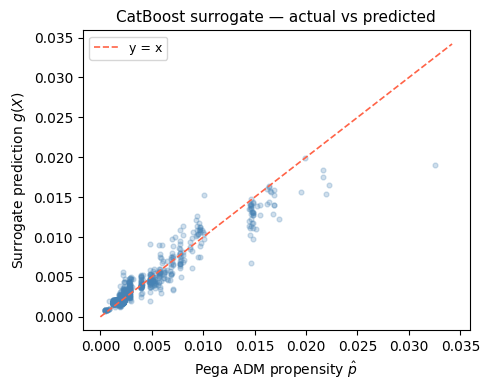

In [9]:
### 7.6  Actual vs predicted (CatBoost)
pred_cb = cb_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_test, pred_cb, alpha=0.25, s=12, color="steelblue")
lim = max(y_test.max(), pred_cb.max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="tomato", lw=1.2, label="y = x")
ax.set_xlabel("Pega ADM propensity $\\hat{p}$")
ax.set_ylabel("Surrogate prediction $g(X)$")
ax.set_title("CatBoost surrogate — actual vs predicted", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

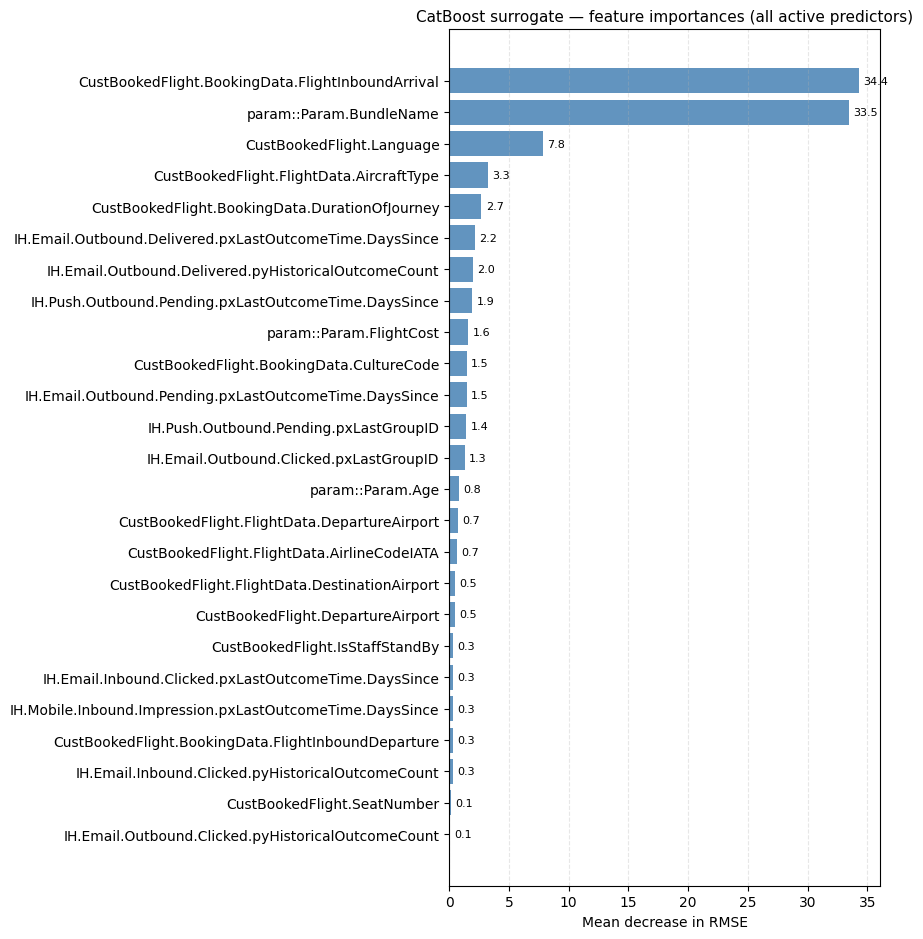

,importance,rank
CustBookedFlight.BookingData.FlightInboundArrival,34.35,1
param::Param.BundleName,33.47,2
CustBookedFlight.Language,7.84,3
CustBookedFlight.FlightData.AircraftType,3.27,4
CustBookedFlight.BookingData.DurationOfJourney,2.70,5
IH.Email.Outbound.Delivered.pxLastOutcomeTime.DaysSince,2.19,6
IH.Email.Outbound.Delivered.pyHistoricalOutcomeCount,1.98,7
IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince,1.95,8
param::Param.FlightCost,1.61,9
CustBookedFlight.BookingData.CultureCode,1.47,10


In [10]:
### 7.7  CatBoost feature importances
importances = pd.Series(
    cb_model.get_feature_importance(),
    index=X_train.columns,
    name="importance",
).sort_values(ascending=False)

ranks = feature_ranking(importances)

fig, ax = plt.subplots(figsize=(9, max(4, len(importances) * 0.38)))
bars = ax.barh(importances.index[::-1], importances.values[::-1], color="steelblue", alpha=0.85)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xlabel("Mean decrease in RMSE")
ax.set_title("CatBoost surrogate — feature importances (all active predictors)", fontsize=11)
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({"importance": importances, "rank": ranks})
    .head(15)
    .style.format({"importance": "{:.2f}", "rank": "{:d}"})
)

In [11]:
### 7.8  Save artifacts
cb_model.save_model(str(ARTIFACT_DIR / "catboost_model.cbm"))

(ARTIFACT_DIR / "feature_cols.json").write_text(json.dumps(list(X.columns)))
(ARTIFACT_DIR / "cat_cols.json").write_text(json.dumps(cat_cols))
(ARTIFACT_DIR / "num_cols.json").write_text(json.dumps(num_cols))

np.save(ARTIFACT_DIR / "train_idx.npy", X_train.index.to_numpy())
np.save(ARTIFACT_DIR / "test_idx.npy",  X_test.index.to_numpy())

(ARTIFACT_DIR / "fidelity.json").write_text(
    json.dumps([cb_fidelity, nb_fidelity], indent=2)
)

print("Artifacts saved:")
for f in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {f.name}")

Artifacts saved:
  cat_cols.json
  catboost_model.cbm
  feature_cols.json
  fidelity.json
  num_cols.json
  test_idx.npy
  train_idx.npy


## 8. Model Version Analysis

Pega ADM updates its Naive Bayes continuously via online learning. Different rows in this dataset were therefore scored by different model snapshots. The metadata fields `modelEvidence` and `modelPerformance` (AUC) track which snapshot was active at scoring time and serve as the model-churn proxy in the instability attribution (notebook 07).

In [12]:
### 8.1  Model version counts and mean propensity per version
print("Version counts:")
print(df["modelVersion"].value_counts(dropna=False).to_string())
print()
print("Mean propensity per version:")
print(df.groupby("modelVersion")["propensity"].mean().sort_values(ascending=False).to_string())

Version counts:
modelVersion
5c2acbce-86df-50a0-b3ba-17a5f6a5270c    446
5ed27c75-0039-5c7f-9bda-d950ccf254df    416
b9116607-3620-526a-96f2-490303931dae    414
c77ad3f1-48a3-5d06-8dcd-376561a6ae52    410
6db6f699-1d07-5d4e-9b7e-54cc1ca6f99b    392
42e89e31-ee09-5bac-96a0-658988831fd7    386
a878af03-6183-53de-9357-1a9b294d3dba    384
3f17039f-88f1-5435-ba32-890ad55b698e    369
ac8ac396-4031-57cf-bf11-54bbf465325b    367
f9161152-526a-5d3b-a24a-21e643a500e3    366
ece43c87-1d4d-5bc3-b310-27e32ab67f25    364
0777b91e-2eda-5471-880a-7a648e983f0f    362
b335bafa-1b51-5662-b6b9-1a8462c839b5    359
267c0f90-0fb5-544e-8be8-9a77ff9cdbdf    350
1af6e524-d196-53e5-8485-c4e133001a00    350
6718038b-cd9f-559f-8ce3-f84f7a09ffbc    344
ca20c65f-6850-5f60-8e6a-2d086c4183a9    336
6e5566c8-fa43-5eb8-8dbc-bd8900fc9e74    319
998c98a1-04bf-5d88-a1df-f1b5c19a7491    317
e1f7c11a-4fbb-5109-95d9-1b75bfe6342a    316
810f32f6-3e75-583f-9af9-364d834fb025    314
16451dfc-db73-521d-a0e2-2ac9bb4a28ec    271
5a4

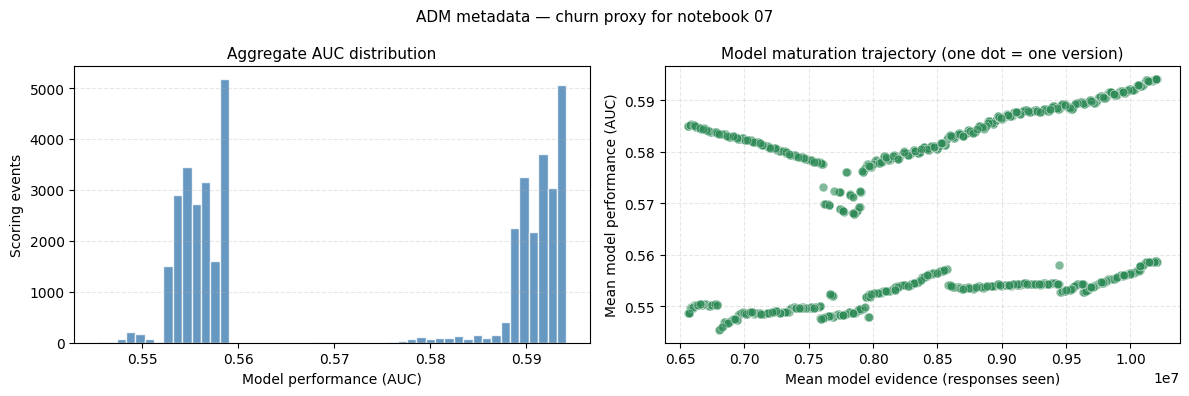

Model versions plotted: 1717


In [13]:
### 8.2  AUC distribution and model maturation trajectory
# Left: aggregate AUC distribution — the bimodal pattern indicates two model
# populations (early low-AUC vs mature high-AUC snapshots) in the window.
# Right: per-version mean AUC vs mean evidence — shows the learning trajectory
# used as the model-churn proxy in the instability attribution (notebook 07).

version_meta = (
    df.groupby("modelVersion")[["modelPerformance", "modelEvidence"]]
    .mean()
    .dropna()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["modelPerformance"].dropna(), bins=50, color="steelblue", alpha=0.82, edgecolor="white")
axes[0].set_xlabel("Model performance (AUC)")
axes[0].set_ylabel("Scoring events")
axes[0].set_title("Aggregate AUC distribution", fontsize=11)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")

axes[1].scatter(
    version_meta["modelEvidence"], version_meta["modelPerformance"],
    alpha=0.6, s=40, color="seagreen", edgecolors="white", linewidths=0.4,
)
axes[1].set_xlabel("Mean model evidence (responses seen)")
axes[1].set_ylabel("Mean model performance (AUC)")
axes[1].set_title("Model maturation trajectory (one dot = one version)", fontsize=11)
axes[1].grid(alpha=0.3, linestyle="--")

plt.suptitle("ADM metadata — churn proxy for notebook 07", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Model versions plotted: {len(version_meta)}")